# Practical 4: Density-based clustering

**Course:** WBCS032-05 Introduction to Machine Learning  
**Student Names:**  Rik de Hoop (s5303893) & Avery Kozák (s5559294)

---

## Assignment Overview

In this assignment, you will implement the Density-based spatial clustering of applications with noise (DBSCAN) algorithm as introduced and discussed in class, using Euclidean distance. Consider different settings for the parameter $minPts = 3,5,7$. Parameter eps will be optimised in the experiments. You will work with the same dataset `data_clustering.csv` used in Practical 2.


## 1. Introduction (1 point)

Describe the goal of this assignment. Your description should cover:

- The **problem** being solved
- The **experiments** performed
- The **algorithm** used
- The **dataset** used

**Your answer here:**

The goal of this assignment is to implement and evaluate the Density-Based Spatial Clustering of Applications with Noise (DBSCAN) algorithm for clustering data points based on density. Clustering is a fundamental task in unsupervised machine learning, where the objective is to group similar data points together without having predefined class labels.

The main problem addressed in this assignment is comparing various potential parameters for the DBSCAN algorithm in order to find the best fit (i.e. the one that yields the most ideal clustering configuration) for our dataset. Clustering analysis, namely that of DBSCAN, centres on identifying meaningful groups of data points while also detecting points that do not belong to any cluster (noise)

Traditional clustering algorithms such as k-means require the number of clusters to be specified in advance and tend to perform poorly when clusters have irregular shapes or when noise is present in the dataset. DBSCAN addresses these limitations by identifying clusters based on regions of high density separated by regions of low density. This allows the algorithm to detect clusters of arbitrary shapes and automatically classify sparse points as noise.

In this assignment, the DBSCAN algorithm is implemented from scratch using Euclidean distance to measure similarity between data points. The algorithm uses two important parameters: $\varepsilon$, which defines the radius of the neighbourhood around a point, and MinPts, which specifies the minimum number of points required to form a dense region.

Then, we attempt to determine optimal values for the parameters of DBSCAN, such that we optimise the goodness-of-fit of remaining clusters - we compare the latter between various parameter configurations by calculating the silhouette scores for the resulting clustering configurations.

Namely, we investigate values of $3, 5, 7$ for the MinPts parameter. Then, in order to determine the optimal $\varepsilon$ value for a given value of MinPts, we generate k-nearest neighbour (KNN) distance graphs.

These graphs plot the distance to the k-th nearest neighbour for each data point, sorted by increasing distance. By identifying a characteristic "elbow point" in the graph (i.e. a "cutoff point" where KNN-distance begins to diverge between two subsections of our feature vectors), a suitable $\varepsilon$ value can be selected that separates these subsections - i.e., dense regions from sparse regions.

After determining the parameter values, the DBSCAN algorithm is applied to the dataset to generate clusters. The results are visualised using scatter plots that show the detected clusters and noise points. In addition to visualisation/"manual" analysis of the resulting plots, the clustering quality is also evaluated by calculating the respective silhouette scores, which measures how well-separated and compact the clusters are.

The dataset used in this assignment is `data_clustering.csv`, which consists of 200 two-dimensional feature vectors.

## 2. Methods (3.5 points)

### 2.1 Explain the DBSCAN algorithm (1 point)

Explain the algorithm in a general manner. Your explanation should describe all three components:
- **`DBSCAN`**: the main function - how it iterates over points and assigns cluster labels
- **`regionQuery`**: how it finds all neighbours within radius $\varepsilon$

- **`expand_cluster`**: how it grows a cluster from a core point


**Your answer here:**

Density Based Spatial Clustering of Applications with Noise is a clustering algorithm that groups together points that are closely packed together and marks points that lie alone in low density regions as noise.

The algorithm uses two parameters:
 - $\varepsilon$, the radius of the neighbourhood around a point.
   - Points whose distance is no more than this (under a distance measure, in our case Euclidean) will be considered part of that point's $\varepsilon$-neighbourhood.
 - MinPts, the minimum number of points required to form a dense region
   - This is the minimum size a point's $\varepsilon$-neighbour must be in order for that point to be marked a _core point_ (and form a new cluster if it hasn't already)

Formally, we also define the notion of _core points_ (whose neighbourhoods are at least MinPts in size) and _border points_ (non-core points inside clusters), and _outliers_ or _noise points_ (which are neither), with the latter being excluded from clustering and ignored.

DBSCAN's clustering operates on the notion of _reachability_: that is, points are reachable from a *core* point, if and only if they are in the neighbourhood of that point. We say two points are densely-connected if a point is mutually reachable from them.

The overall idea is that DBSCAN forms clusters such that all points in a cluster are *mutually densely-connected* - i.e. all points reachable from a cluster are part of that cluster as well.

The algorithm consists of three main components:
 - regionQuery function:
    - Finds all points in the data withing the epsilon range of a point. Simply compares all points with all other points and adds them as neighbors if they're within the epsilon range.
 - expand_cluster function:
    - Grows a cluster from a core point. It assigns the current cluster label to the point and its neighbors. If any of those neighbors are also core points, then their neighbors are also added to the cluster. This process continues, expanding the cluster along $\varepsilon$-neighbourhoods, until no more points can be added to the cluster.
    - In essence, the function adds all points reachable from a core point to the cluster, and then all points reachable from any of the core points among these newly added points, and so on.
 - DBSCAN:
    - This function iterates through all points in the dataset. Every point it checks whether the point has been visited. If not, the algorithm uses regionQuery to finds its neigbors. If the number of neighbors is smaller than MinPts, then it will be labeled as noise. If it has equal or more, it's considered a core point and a new cluster is created, on which the expand_cluster function is called - growing the cluster as far as possible while maintaining that its points form one, overarching, densely-connected region.

### 2.2 Implementation (2.5 points)

You need to implement the DBSCAN algorithm **yourself**. Code and implementation itself will also be taken into account for the grading of this section.


*__Note:__* **Do not change the cell labels! Themis will use them to automatically grade your submission.**

In [3]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Data configuration
data_file_path = "data_clustering.csv"


In [4]:
# Read input data
df = pd.read_csv(data_file_path, header=None)
data = np.array(df)


In [5]:
def DBSCAN(D, eps, MinPts):
    """
    Density-based spatial clustering of applications with noise (DBSCAN)

    Args:
        D (ndarray):Data points.
        eps(float): The radius of the neighbourhood around a data point
        MinPts(int): The minimum number of points to form a dense region

    Return:
      labels (ndarray): The corresponding cluster labels.

    """
    labels = np.zeros(len(D), dtype=int)
    cluster_id = 0

    for i in range(len(D)):
        if labels[i] != 0:
            continue
        neighbors = regionQuery(D, i, eps)
        if len(neighbors) < MinPts:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(D, labels, i, neighbors, cluster_id, eps, MinPts)
    return labels


def regionQuery(D, point_idx, eps):
    """
    Return indices of all points within eps of point_idx.

    Args:
        D (ndarray):Data points.
        point_idx(int): The index of the point
        eps(float): The radius of the neighbourhood around a data point

    Return:
      neighbors (list): The indices of all points within eps of point_idx.

    """
    neighbors = []

    for i in range(len(D)):
        dist = np.linalg.norm(D[point_idx] - D[i])
        if dist <= eps:
            neighbors.append(i)
    return neighbors


def expand_cluster(D, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    """
    Expand the cluster with cluster_id from the seed point point_idx.

    Args:
        D (ndarray):Data points.
        labels (ndarray): The corresponding cluster labels.
        neighbors (list): The indices of all points within eps of point_idx.
        point_idx(int): The index of the point
        eps(float): The radius of the neighbourhood around a data point
        min_samples (int): The minimum number of points to form a dense region

    """
    labels[point_idx] = cluster_id
    i = 0

    while i < len(neighbors):
        neighbor_point = neighbors[i]
        if labels[neighbor_point] == -1:
            labels[neighbor_point] = cluster_id
        elif labels[neighbor_point] == 0:
            labels[neighbor_point] = cluster_id
            new_neighbors = regionQuery(D, neighbor_point, eps)
            if len(new_neighbors) >= min_samples:
                neighbors += new_neighbors
        i += 1


## 3. Experimental Results (3.5 points)

### 3.1 KNN graphs

*__Note:__* This section **is graded** by Themis.

Implement the function below to plot the $k$-nearest neighbour distance graph. Mark one possible elbow point on each plot to indicate the threshold value for parameter $\varepsilon$.

You can use `sklearn.neighbors.NearestNeighbors(n_neighbors=k)` for the k-nearest neighbour search/graph.


In [8]:
def plot_knn(D, k, y=None):
    """
    Plot the k-nearest neighbour distance graph.

    Args:
        D (ndarray): Data points.
        k (int): Number of nearest neighbours.
        y (float, optional): Threshold value for eps. If provided, draws a
                             horizontal dashed line at this value.
    """
    
    # get knn distance for each point
    dists, _ = NearestNeighbors(n_neighbors=k).fit(D).kneighbors(D)
    knn = dists[:, k-1] # i.e. for each point, the distance of the k-th nearest neighbour
    
    # sort knn distances (increasing order; we don't actually need the points)
    knn_sorted = np.sort(knn)

    plt.figure()
    plt.plot(range(len(knn_sorted)), knn_sorted)
    if (y != None):
        col=y
        plt.axhline(col, linestyle='--')
    plt.title(str(k) + " Nearest Neighbor graph")
    plt.xlabel("Points sorted by distance")
    plt.ylabel(str(k) + "-Nearest Neighbor Distance")



Let's investigate the values $MinPts = 2,3,4,5,7$ explicitly:

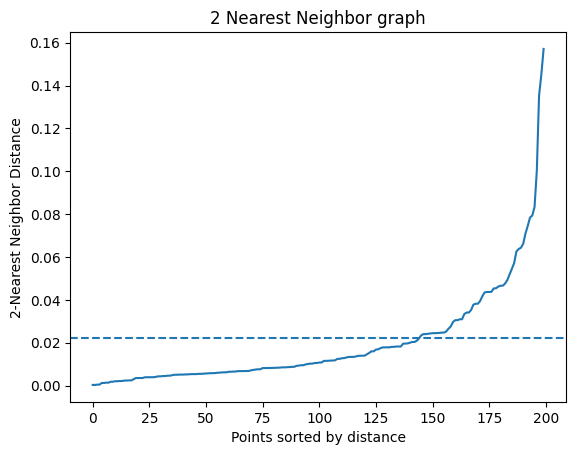

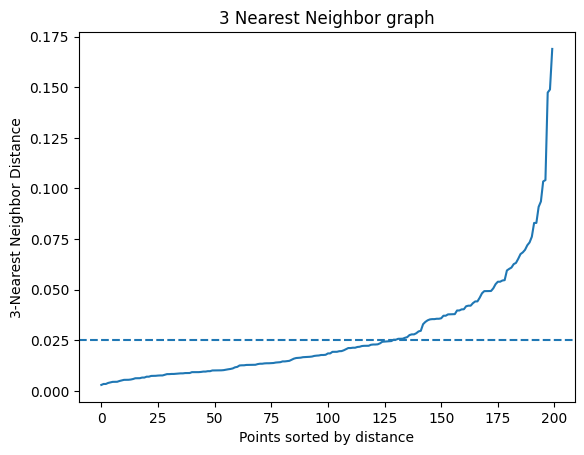

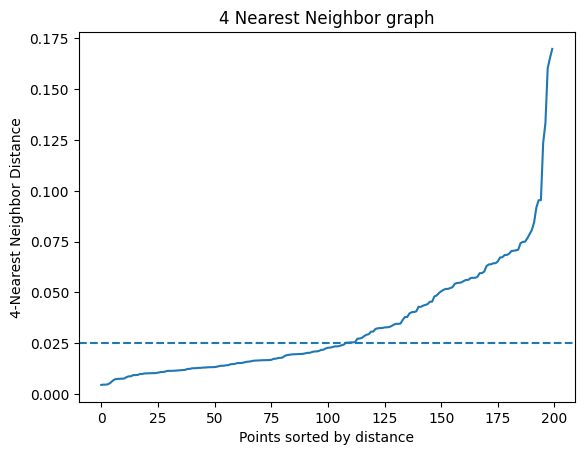

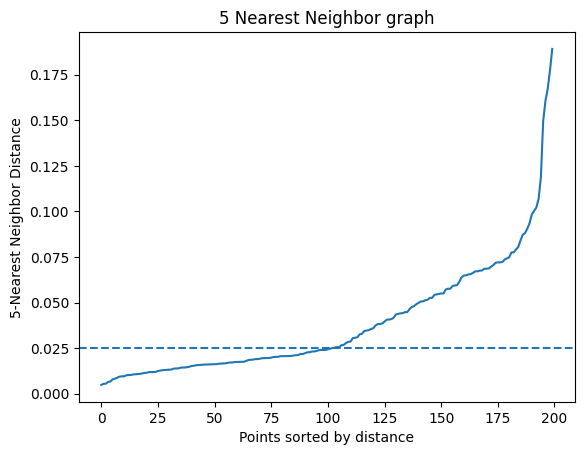

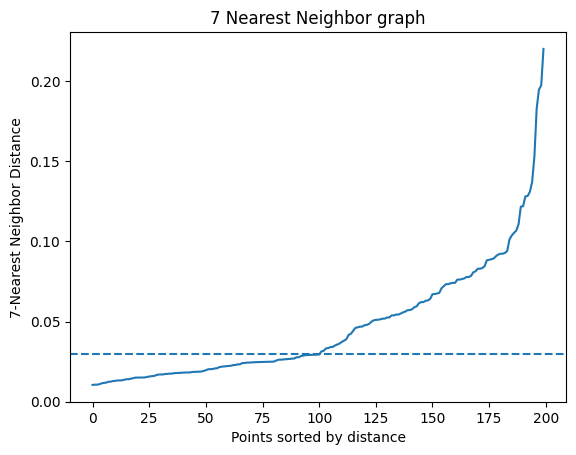

In [9]:
plot_knn(data, 2, 0.022)
plot_knn(data, 3, 0.025)
plot_knn(data, 4, 0.025)
plot_knn(data, 5, 0.025)
plot_knn(data, 7, 0.03)

From the KNN graphs, we can read off (close to) optimal values for $\varepsilon$: at $k=2$, this is $0.022$, for $k=7$ around $0.03$, and for other values this is more or less $0.025$.

Most of these graphs have _two_ distinct points where the KNN-distance suddenly accelerates. However, out of these, there is consistently a promising cutoff value in the vicinity of $0.025$, and our experimentation has found that across all potential epsilons for a graph, we tend to find the best silhouette scores with one in this vicinity.

These values also strike a nice balance: in addition to corresponding to the "acceleration" of the KNN-graph, they also intersect with the curve horizontally "in the middle" on the graph - this means the $\varepsilon$ value leads neither to too many points being clustered together (and thereby sparse, "bad" clusters) nor to too many points being marked as outliers.

### 3.2 Clustering results

_**Note:**_ This section **is graded** by Themis.

Implement the function below to perform DBSCAN clustering and plot the resulting clusters and outliers, for the $\varepsilon$ and $minPts$ values found in 3.1.


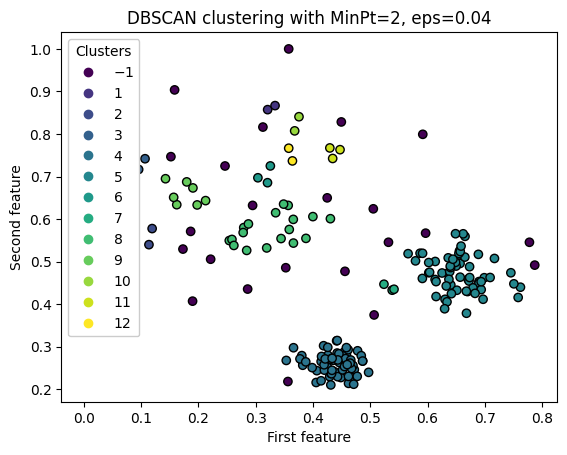

In [ ]:
def plot_db_scan(D, eps, k):
    """
    Perform DBSCAN and plot the resulting clusters.

    Args:
        D (ndarray): Data points.
        eps (float): The radius of the neighbourhood around a data point.
        k (int): The minimum number of points to form a dense region (MinPts).
    """
    # perform DBSCAN
    labels = DBSCAN(D, eps, k)

    # plot the points by cluster
    scatter = plt.scatter(D[:, 0], D[:, 1], c=labels, edgecolors='black')
    plt.xlabel("First feature")
    plt.ylabel("Second feature")
    plt.title("DBSCAN clustering with MinPt=" + str(k) + ", eps=" + str(eps))

    # use label numbers (outlier = -1) directly as legend values
    handles, sc_labels = scatter.legend_elements(num=len(np.unique(labels)))
    handles, sc_labels = np.delete(handles, 1), np.delete(sc_labels, 1)
    plt.legend(handles, sc_labels, title="Clusters", framealpha=1)

# test code
#plot_db_scan(data, 0.04, 2)


### 3.3 Quantitative result

*__Note:__* This section **is not graded** by Themis.

Compute and return the silhouette score for the different parameter settings found in 3.1 (in total, 3 silhouette scores). You can use `sklearn.metrics.silhouette_score`.


In [12]:
# Compute silhouette scores for the parameter settings found in section 3.1
# Replace eps_values and minpts_values with the values you determined

minpts_values = [2, 3, 4, 5, 7]
eps_values = [0.022, 0.025, 0.025, 0.025, 0.03]
silhouette_scores = []
for i in range(len(minpts_values)):
  labels = DBSCAN(data, eps_values[i], minpts_values[i])
  # exclude outliers (= noise) from silhouette score calculation
  outlier_indices = np.where(labels == -1)
  real_data = np.delete(data, outlier_indices, axis=0)
  real_labels = np.delete(labels, outlier_indices)
  silhouette_scores.append(silhouette_score(real_data, real_labels))

print("Silhouette scores:")
for i in range(len(minpts_values)):
  print("MinPts=" + str(minpts_values[i]) + ", eps=" + str(eps_values[i]) + ":")
  print("     Silhouette score: S=" + str(round(silhouette_scores[i], 5)))

Silhouette scores:
MinPts=2, eps=0.022:
     Silhouette score: S=0.50459
MinPts=3, eps=0.025:
     Silhouette score: S=0.57398
MinPts=4, eps=0.025:
     Silhouette score: S=0.80869
MinPts=5, eps=0.025:
     Silhouette score: S=0.81129
MinPts=7, eps=0.03:
     Silhouette score: S=0.81537


Fill in the silhouette scores obtained for each parameter setting:

| $k$ (MinPts) | $\varepsilon$ | Silhouette Score |
|:---:|:---:|:---:|
| 2 | 0.022 | 0.5046 |
| 3 | 0.025 | 0.5740 |
| 4 | 0.025 | 0.8087 |
| 5 | 0.025 | 0.8113 |
| 7 | 0.03 | 0.8154 |

## 4. Discussion (2 points)

Discuss your observations on both the qualitative and quantitative results, and conclusions for the best choice of parameter settings.

**Your answer here:**

Based on the KNN-graphs, we are confident our values for $\varepsilon$ are quite good for each value of MinPts.

We can thereby see that a MinPts value of 3 or lower leads to a quite poor silhouette score, which indicates a poor clustering configuration.

The likeliest cause for this is that the resulting clusters are poorly separated, likely because they're made up of very small neighbourhoods that are just isolated enough to not form bigger clusters, but not enough to be dismissed as outliers. This is backed up by the KNN graphs: namely, given our $\varepsilon$ values are inside the "elbow", increasing them just a tiny bit further would lead to an explosive increase in cluster sizes.

Looking at our data set, we can see that there is a considerable spread amongst feature vectors (namely, on the region where feature 1 $\in$ [0.0,0.5], feature 2 $\in$ [0.5,1.0]) - it's reasonable to conclude that many of these points, which with a higher MinPts value would be dismissed as noise, form very tiny clusters which are just barely distant enough to not be merged, but not distant enough to actually lead to sufficient separation.

It's also fairly likely that these points _are_, indeed, noise - or at the very least do not form coherent, compact clusters.

For MinPts values of 4 or higher, however, our silhouette score sees considerable improvement, at a quite agreeable value of around 0.8. Furthermore, we see an upwards trend as we increase MinPts further (at least up to 7) - the likely reason is that a higher MinPts value leads to more of the aforementioned "noise points" being marked as outliers rather than being clustered.

In conclusion, across all of these values, the ideal configuration is attained with MinPts=7, $\varepsilon=0.03$, although MinPts=4 and especially MinPts=5 (both with $\varepsilon=0.025$) are very close contenders.

Across the values $\{3, 5, 7\}$, our ideal candidate is MinPts=7, closely followed by 5, with MinPts=3 leading to fairly poor clustering.

Across the values $\{2, 3, 4\}$, our ideal candidate is without a doubt MinPts=4 as mentioned above, with both 2 and 3 leading to poor results.


## Contribution

State your individual contribution.

**Your answer here:**

Rik: 1 and 2, some bugfixing

Avery: 3 and 4